In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MultiMLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: mps


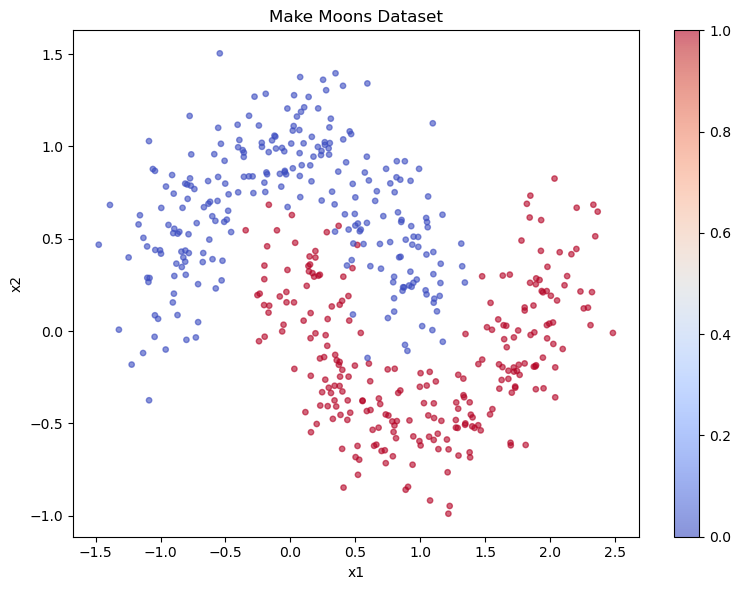

In [2]:
from sklearn.datasets import make_moons, make_circles
from torch.utils.data import TensorDataset

# Generate toy binary classification datasets
N_TRAIN = 500
N_TEST = 100
NOISE = 0.2

X_train, y_train = make_moons(n_samples=N_TRAIN, noise=NOISE, random_state=42)
X_test, y_test = make_moons(n_samples=N_TEST, noise=NOISE, random_state=43)

# Convert to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# Visualize the dataset
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, s=15)
ax.set_title('Make Moons Dataset')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
plt.colorbar(scatter)
plt.tight_layout()

In [3]:
NUM_MODELS = 10

set_seed(437438)
mlp_base = MultiMLP(
    num_models=NUM_MODELS,
    input_dim=2,
    hidden_dims=[32, 32, 32],
    output_dim=2
)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base

In [4]:
LOADER_SEED = 645297
batch_size = 128
n_epoch = 20
K = 128
RTOL = 1e-2
LR = 1e-3

### Train MultiMLP ensemble with Adam

In [5]:
model_adam = MultiMLP(num_models=NUM_MODELS, input_dim=2, hidden_dims=[32, 32, 32], output_dim=2)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=1e-3)

def loss_fn_adam(pred, y):
    if pred.dim() == 3:
        M, B, C = pred.shape
        pred = pred.reshape(M * B, C)
        y = y.unsqueeze(0).expand(M, -1).reshape(M * B)
    return F.cross_entropy(pred, y)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn_adam, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device mps


100%|██████████| 20/20 [00:01<00:00, 16.31it/s]


### Train MultiMLP ensemble with SVD Optimizer

In [6]:
if device == torch.device('mps'):
    device = torch.device('cpu')

model_svd = MultiMLP(num_models=NUM_MODELS, input_dim=2, hidden_dims=[32, 32, 32], output_dim=2)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn_svd(pred, y):
    if pred.dim() == 3:
        M, B, C = pred.shape
        pred = pred.reshape(M * B, C)
        y = y.unsqueeze(0).expand(M, -1).reshape(M * B)
    return F.cross_entropy(pred, y, reduction='none')

model_svd = FunctionalModelJac(model_svd, loss_fn_svd, device=device)
optimizer = SVDOptimizer(model_svd, lr=LR, k=K, rtol=RTOL, track_svd_info=True, svd_mode='randomized', use_rmsprop=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd, optimizer, loss_fn_svd, train_loader, test_loader, n_epoch, device, track_acc=True)
svd_info = optimizer.svd_info

torch.compiler.reset()

  0%|          | 0/20 [00:00<?, ?it/s]/Users/sambt/miniforge3/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
100%|██████████| 20/20 [00:56<00:00,  2.85s/it]


### Compare Adam vs SVD

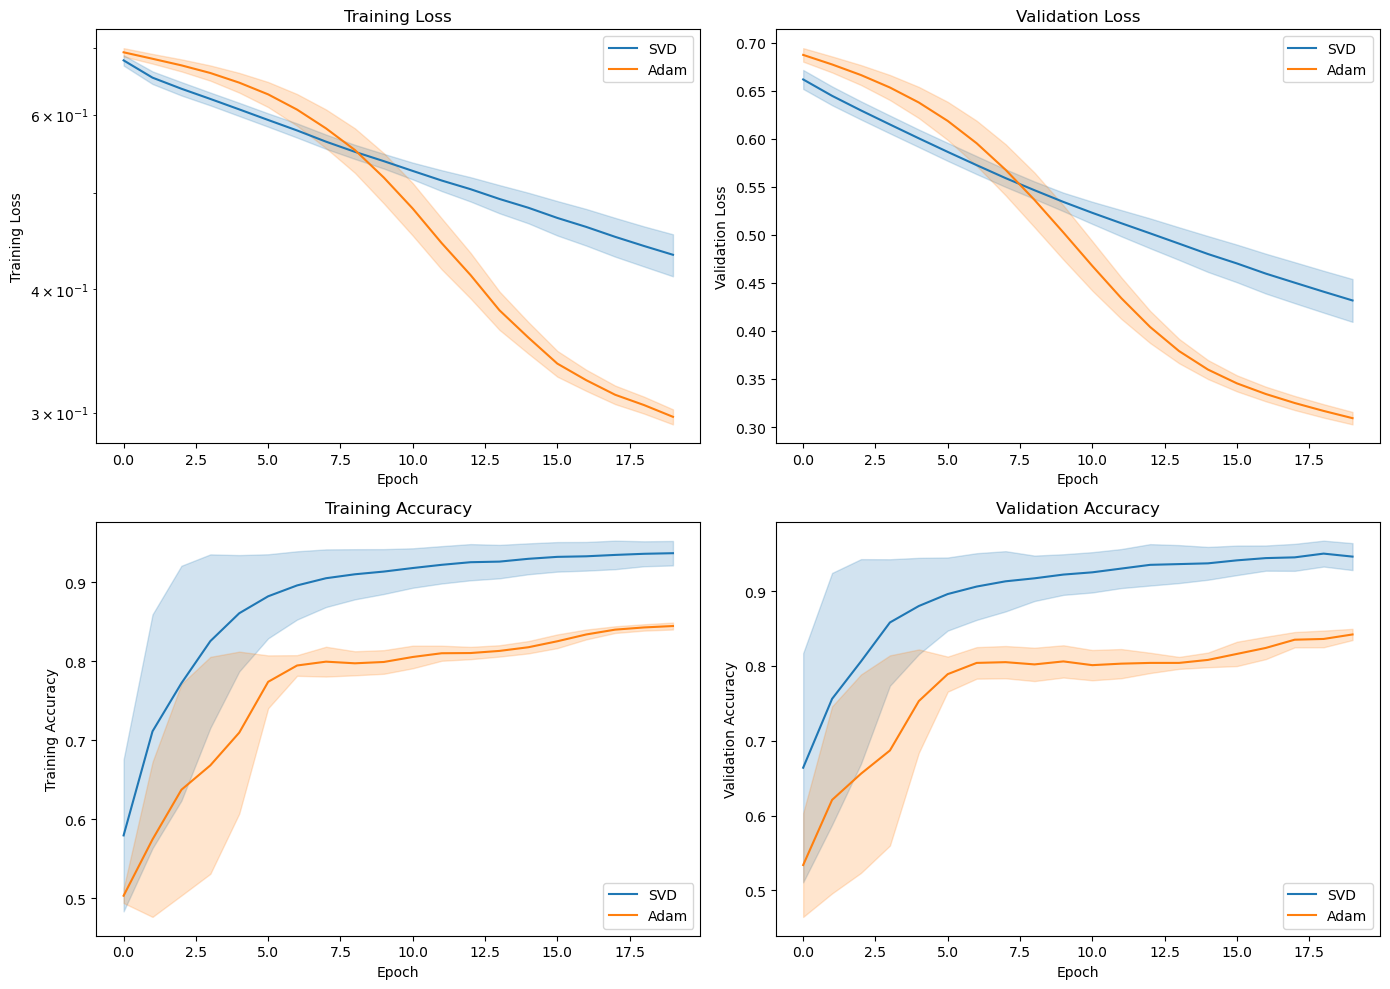

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = np.arange(len(losses_adam['train']))

for ax, key, title in [
    (axes[0, 0], 'train', 'Training Loss'),
    (axes[0, 1], 'val', 'Validation Loss'),
    (axes[1, 0], 'train_acc', 'Training Accuracy'),
    (axes[1, 1], 'val_acc', 'Validation Accuracy'),
]:
    for losses_dict, label, color in [
        (losses_svd, 'SVD', 'C0'),
        (losses_adam, 'Adam', 'C1'),
    ]:
        pm = np.array(losses_dict[f'{key}_per_model'])  # (num_epochs, M)
        mean = pm.mean(axis=1)
        std = pm.std(axis=1)
        ax.plot(epochs, mean, color=color, label=label)
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()

axes[0, 0].set_yscale('log')
plt.tight_layout()

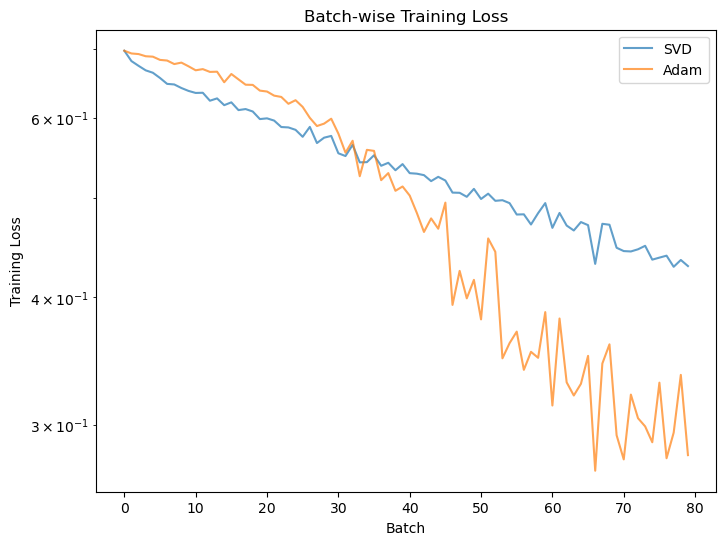

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(losses_svd['train_batch'], label='SVD', alpha=0.7)
plt.plot(losses_adam['train_batch'], label='Adam', alpha=0.7)
plt.legend()
plt.ylabel("Training Loss")
plt.xlabel("Batch")
plt.title("Batch-wise Training Loss")
plt.yscale('log')

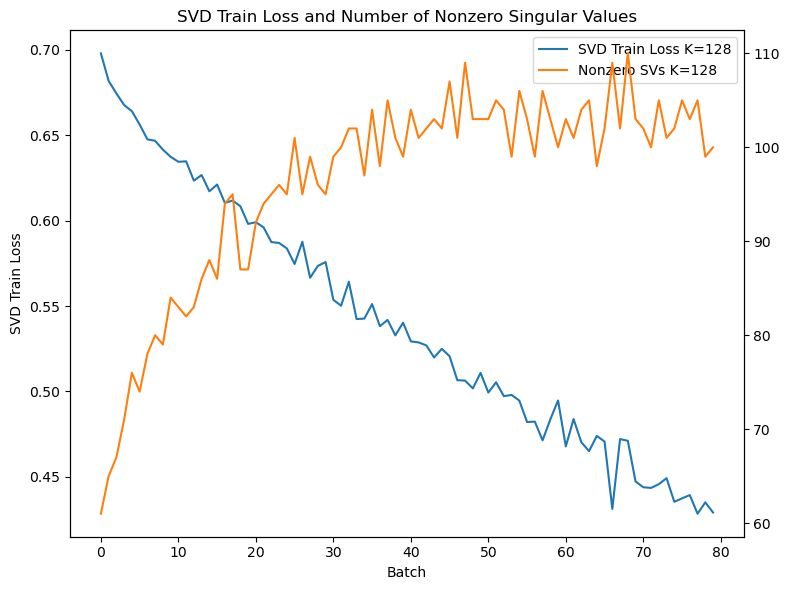

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 6))

p1 = ax1.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], 'C0', label=f'SVD Train Loss K={K}')
ax1.set_xlabel('Batch')
ax1.set_ylabel('SVD Train Loss')

ax2 = ax1.twinx()
p2 = ax2.plot(np.arange(len(svd_info['num_nonzero_svs'])), svd_info['num_nonzero_svs'], 'C1-', label=f'Nonzero SVs K={K}')

ax1.legend(handles=[p1[0], p2[0]])
plt.title("SVD Train Loss and Number of Nonzero Singular Values")
plt.tight_layout()

### Decision Boundaries

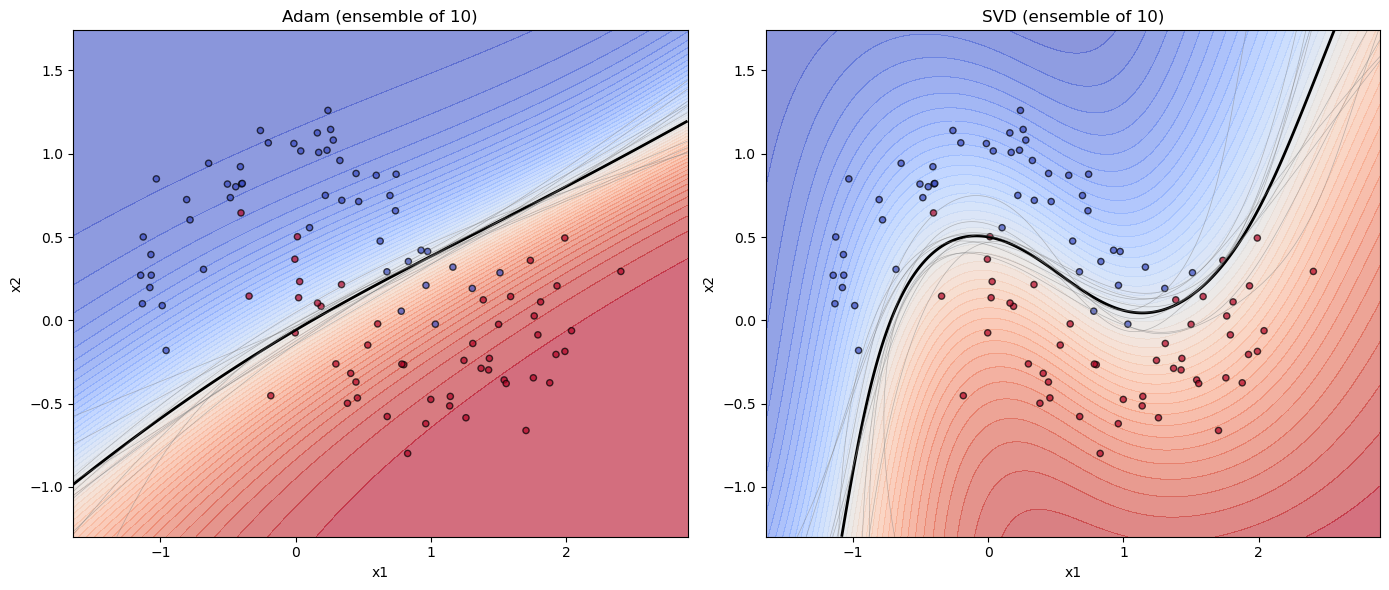

In [10]:
def plot_decision_boundary(model, X, y, title, ax, is_functional=False):
    """Plot decision boundary for a 2D classifier. For MultiMLP, shows ensemble mean with individual boundaries."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        if is_functional:
            logits = model.evaluate(grid)
        else:
            model.eval()
            logits = model(grid)
        
        if logits.dim() == 3:
            # MultiMLP: (num_models, grid_points, classes)
            all_probs = torch.softmax(logits, dim=2)[:, :, 1].cpu().numpy()  # (M, N)
            probs = all_probs.mean(axis=0)  # ensemble mean
        else:
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs = None
    
    probs = probs.reshape(xx.shape)
    
    ax.contourf(xx, yy, probs, levels=50, cmap='coolwarm', alpha=0.6)
    # Ensemble mean boundary
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=2)
    # Individual model boundaries
    if all_probs is not None:
        for i in range(all_probs.shape[0]):
            ax.contour(xx, yy, all_probs[i].reshape(xx.shape), levels=[0.5], colors='gray', linewidths=0.5, alpha=0.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(model_adam.to('cpu'), X_test, y_test, f'Adam (ensemble of {NUM_MODELS})', axes[0])
plot_decision_boundary(model_svd, X_test, y_test, f'SVD (ensemble of {NUM_MODELS})', axes[1], is_functional=True)

plt.tight_layout()